In [23]:
from pathlib import Path
import importlib.util
import json
import os
import random
import shutil
import subprocess
import sys
from collections import Counter
from dataclasses import dataclass

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CACHE_ROOT = PROJECT_ROOT / ".cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("YOLO_CONFIG_DIR", str(CACHE_ROOT / "ultralytics"))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
os.environ.setdefault("KAGGLEHUB_CACHE", str(CACHE_ROOT / "kagglehub"))
for folder in ["ultralytics", "matplotlib", "kagglehub"]:
    (CACHE_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("Python:", sys.executable)
print("Python version:", sys.version)
print("Project root:", PROJECT_ROOT)

if sys.version_info[:2] != (3, 14):
    print("WARNING: Notebook dang khong chay Python 3.14. Hay chon kernel Python 3.14 trong VS Code neu ban muon dung 3.14.")

# Windows Application Control / Smart App Control can block torch DLL/PYD files in Python 3.14 user site-packages.
# Try to remove Mark-of-the-Web streams before importing torch/ultralytics.
def unblock_torch_windows_files():
    if os.name != "nt":
        return
    candidates = []
    for site_root in [Path(p) for p in sys.path if "site-packages" in p.lower()]:
        torch_root = site_root / "torch"
        if torch_root.exists():
            candidates.append(torch_root)
    for torch_root in candidates:
        files = list(torch_root.rglob("*.dll")) + list(torch_root.rglob("*.pyd"))
        if not files:
            continue
        try:
            subprocess.run(
                ["powershell", "-NoProfile", "-ExecutionPolicy", "Bypass", "-Command", f"Get-ChildItem -LiteralPath '{torch_root}' -Recurse -Include *.dll,*.pyd | Unblock-File"],
                check=False,
                capture_output=True,
                text=True,
            )
            print(f"Checked/unblocked torch binary files in: {torch_root}")
        except Exception as exc:
            print("Could not run Unblock-File for torch binaries:", exc)

unblock_torch_windows_files()

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "yaml": "PyYAML",
    "ultralytics": "ultralytics",
    "kagglehub": "kagglehub",
}

missing = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module_name) is None]
if missing:
    print("Installing missing packages into current Python 3.14 kernel:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    unblock_torch_windows_files()

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, display

try:
    from ultralytics import YOLO
except OSError as exc:
    message = str(exc)
    if "Application Control policy" in message or "torch_global_deps.dll" in message:
        raise RuntimeError(
            "Python 3.14 dang bi Windows Application Control chan torch DLL. "
            "Notebook da thu Unblock-File nhung chua thanh cong. "
            "Hay chay PowerShell: Get-ChildItem $env:LOCALAPPDATA\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\torch -Recurse -Include *.dll,*.pyd | Unblock-File "
            "roi restart kernel, hoac cai lai torch trong moi truong Python 3.14 duoc Windows tin cay."
        ) from exc
    raise

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


Python: /usr/bin/python3
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Project root: /content


## 1.1. Utility Helpers

Nhung helper nay thay the script `.py` ben ngoai de notebook tu chua toan bo logic xu ly.

In [24]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def display_styled_table(df: pd.DataFrame, caption: str | None = None, max_rows: int = 20):
    view = df.head(max_rows).copy()
    styler = view.style.set_table_styles([
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "bold")]},
        {"selector": "th", "props": [("background", "#1f2937"), ("color", "white")]},
    ])
    if caption:
        styler = styler.set_caption(caption)
    display(styler)

def write_yaml(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(yaml.safe_dump(data, sort_keys=False, allow_unicode=True), encoding="utf-8")

def read_yaml(path: Path) -> dict:
    return yaml.safe_load(path.read_text(encoding="utf-8")) or {}

def normalize_names(names) -> dict[int, str]:
    if isinstance(names, list):
        return {i: str(name) for i, name in enumerate(names)}
    return {int(k): str(v) for k, v in names.items()}

def link_or_copy(source: Path, destination: Path, use_copy: bool = False):
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        destination.unlink()
    if use_copy:
        shutil.copy2(source, destination)
        return
    try:
        destination.hardlink_to(source)
    except OSError:
        shutil.copy2(source, destination)

def label_path_for_image(image_path: Path, images_dir: Path) -> Path:
    relative = image_path.relative_to(images_dir)
    return images_dir.parent.parent / "labels" / images_dir.name / relative.with_suffix(".txt")

def read_yolo_label(label_path: Path) -> list[dict]:
    rows = []
    if not label_path.exists():
        return rows
    for line_no, raw_line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), 1):
        line = raw_line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) != 5:
            rows.append({"error": f"invalid format at line {line_no}: {line}"})
            continue
        try:
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
            rows.append({
                "class_id": class_id,
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height,
                "area": width * height,
            })
        except ValueError:
            rows.append({"error": f"non numeric label at line {line_no}: {line}"})
    return rows

def resolve_split_dir(data_yaml: Path, split: str) -> Path:
    cfg = read_yaml(data_yaml)
    root = Path(cfg.get("path", data_yaml.parent))
    if not root.is_absolute():
        root = (data_yaml.parent / root).resolve()
    split_path = Path(cfg[split])
    return split_path if split_path.is_absolute() else root / split_path

## 1.2. End-to-End Processing Flow

In [25]:
display(HTML("""
<div style="font-family:Arial; max-width:900px;">
  <div style="padding:12px; background:#e8f1ff; border:1px solid #9db7df; border-radius:10px; text-align:center;color:#000000;"><b>Data Collection</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#e9f8ef; border:1px solid #96c5a4; border-radius:10px; text-align:center;color:#000000;"><b>Exploring Data Analysis</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#f2efff; border:1px solid #aea6db; border-radius:10px; text-align:center;color:#000000;"><b>Data Cleaning</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#fff5df; border:1px solid #d6bc7b; border-radius:10px; text-align:center;color:#000000;"><b>Data Preparing</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#fdecea; border:1px solid #d9aaa2; border-radius:10px; text-align:center;color:#000000;"><b>Model Training</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#edf7e7; border:1px solid #a8c991; border-radius:10px; text-align:center;color:#000000;"><b>Evaluation</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#fce7f3; border:1px solid #d59ab8; border-radius:10px; text-align:center;color:#000000;"><b>Inference</b></div>
</div>
"""))

## **`2. Data Collection`**

Tai dataset Kaggle va chuan hoa sang YOLO structure.

In [26]:
from pathlib import Path
import kagglehub, random, shutil

KAGGLE_DATASET = "ahemateja19bec1025/traffic-sign-dataset-classification"

DATA_ROOT = Path("/content/data")
CLS_ROOT = DATA_ROOT / "processed" / "traffic-sign-classification"

downloaded_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
print("Downloaded path:", downloaded_path)

def has_images(folder):
    return any(p.suffix.lower() in IMAGE_EXTENSIONS for p in folder.iterdir() if p.is_file())

def find_class_root(root):
    candidates = []
    for p in [root, *[x for x in root.rglob("*") if x.is_dir()]]:
        class_dirs = [d for d in p.iterdir() if d.is_dir() and has_images(d)]
        if len(class_dirs) >= 2:
            image_count = sum(len([f for f in d.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS]) for d in class_dirs)
            candidates.append((p, image_count))
    if not candidates:
        raise FileNotFoundError("Không tìm thấy folder dạng class_name/*.jpg")
    return max(candidates, key=lambda x: x[1])[0]

CLASS_SOURCE_ROOT = find_class_root(downloaded_path)
print("Class source root:", CLASS_SOURCE_ROOT)

if CLS_ROOT.exists():
    shutil.rmtree(CLS_ROOT)

rng = random.Random(42)
rows = []

for class_dir in sorted([d for d in CLASS_SOURCE_ROOT.iterdir() if d.is_dir()]):
    images = [p for p in class_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS]
    if not images:
        continue

    rng.shuffle(images)
    n = len(images)
    n_val = max(1, int(n * 0.15))
    n_test = max(1, int(n * 0.15))

    split_items = {
        "test": images[:n_test],
        "val": images[n_test:n_test + n_val],
        "train": images[n_test + n_val:],
    }

    for split, paths in split_items.items():
        for i, src in enumerate(paths):
            dst = CLS_ROOT / split / class_dir.name / f"{i:05d}_{src.name}"
            link_or_copy(src, dst)
            rows.append({"split": split, "class_name": class_dir.name, "image_path": dst})

images_df = pd.DataFrame(rows)
display_styled_table(images_df.groupby(["split", "class_name"]).size().reset_index(name="images"), "Classification Dataset")

Using Colab cache for faster access to the 'traffic-sign-dataset-classification' dataset.
Downloaded path: /kaggle/input/traffic-sign-dataset-classification
Class source root: /kaggle/input/traffic-sign-dataset-classification/traffic_Data/DATA


,split,class_name,images
0,test,0,17
1,test,1,6
2,test,10,10
3,test,11,20
4,test,12,14
5,test,13,5
6,test,14,19
7,test,15,3
8,test,16,21
9,test,17,19


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **2.1. Convert Kaggle Dataset to YOLO Split**

In [28]:
def has_images(folder: Path) -> bool:
    return any(
        p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        for p in folder.iterdir()
    )

def find_classification_root(root: Path) -> Path:
    root = Path(root)
    candidates = []

    for path in [root, *[p for p in root.rglob("*") if p.is_dir()]]:
        class_dirs = [
            d for d in path.iterdir()
            if d.is_dir() and has_images(d)
        ]
        if len(class_dirs) >= 2:
            image_count = sum(
                len([f for f in d.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS])
                for d in class_dirs
            )
            candidates.append((path, image_count))

    if not candidates:
        raise FileNotFoundError("Khong tim thay cau truc classification dang class_name/*.jpg")

    return max(candidates, key=lambda item: item[1])[0]


CLASS_SOURCE_ROOT = find_classification_root(downloaded_path)
CLASSIFICATION_ROOT = DATA_ROOT / "processed" / "traffic-sign-classification"

if CLASSIFICATION_ROOT.exists():
    shutil.rmtree(CLASSIFICATION_ROOT)

rng = random.Random(42)
records = []

for class_dir in sorted([p for p in CLASS_SOURCE_ROOT.iterdir() if p.is_dir()]):
    images = sorted([
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    if not images:
        continue

    rng.shuffle(images)

    n = len(images)
    val_count = max(1, int(n * 0.15))
    test_count = max(1, int(n * 0.15))

    split_map = {
        "test": images[:test_count],
        "val": images[test_count:test_count + val_count],
        "train": images[test_count + val_count:],
    }

    for split, split_images in split_map.items():
        for index, source in enumerate(split_images):
            target = CLASSIFICATION_ROOT / split / class_dir.name / f"{index:05d}_{source.name}"
            link_or_copy(source, target)
            records.append({
                "split": split,
                "class_name": class_dir.name,
                "image_path": str(target),
            })

images_df = pd.DataFrame(records)

display_styled_table(
    images_df.groupby(["split", "class_name"]).size().reset_index(name="images"),
    "Classification Dataset",
    120,
)

RUNTIME_DATA_ROOT = CLASSIFICATION_ROOT
print("Classification dataset root:", RUNTIME_DATA_ROOT)

,split,class_name,images
0,test,0,17
1,test,1,6
2,test,10,10
3,test,11,20
4,test,12,14
5,test,13,5
6,test,14,19
7,test,15,3
8,test,16,21
9,test,17,19


Classification dataset root: /content/data/processed/traffic-sign-classification


## **`3. Exploratory Data Analysis (EDA)`**

,class_id,class_name
0,0,0
1,1,1
2,2,10
3,3,11
4,4,12
5,5,13
6,6,14
7,7,15
8,8,16
9,9,17


,split,class_name,images
113,test,0,17
114,test,1,6
115,test,10,10
116,test,11,20
117,test,12,14
118,test,13,5
119,test,14,19
120,test,15,3
121,test,16,21
122,test,17,19


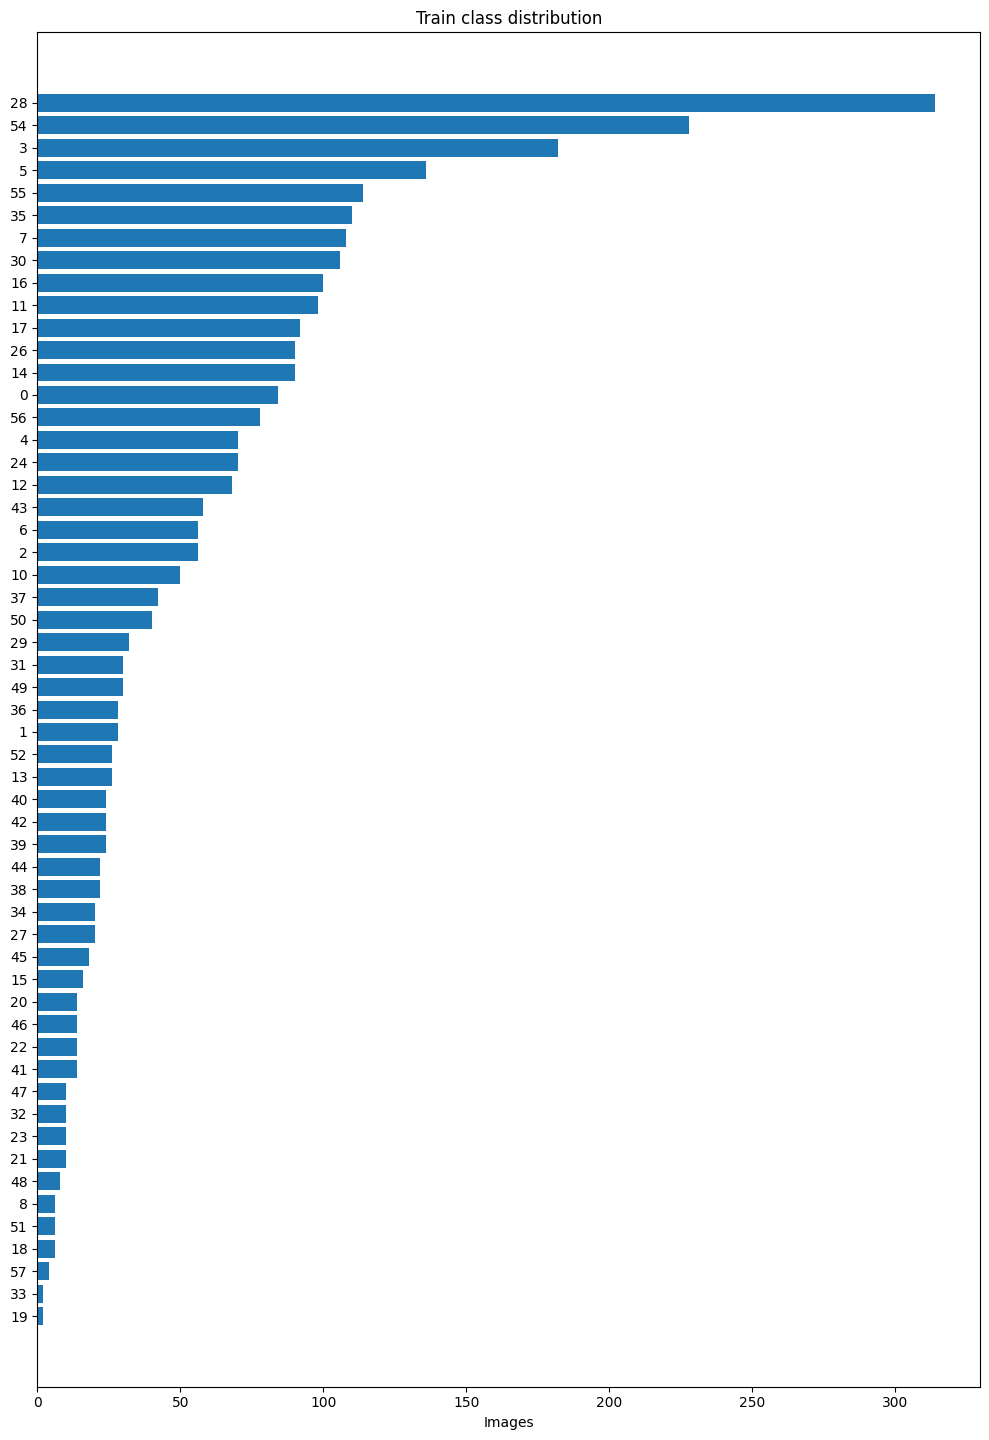

Dataset root: /content/data/processed/traffic-sign-classification
Classes: 55


In [30]:
DATASET_ROOT = RUNTIME_DATA_ROOT if "RUNTIME_DATA_ROOT" in globals() else CLASSIFICATION_ROOT

class_dirs = sorted([
    p for p in (DATASET_ROOT / "train").iterdir()
    if p.is_dir()
])

names = {i: class_dir.name for i, class_dir in enumerate(class_dirs)}

display_styled_table(
    pd.DataFrame({
        "class_id": list(names.keys()),
        "class_name": list(names.values()),
    }),
    "Class Map",
    120,
)

records = []

for split in ["train", "val", "test"]:
    split_dir = DATASET_ROOT / split
    if not split_dir.exists():
        continue

    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        image_count = len([
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ])

        records.append({
            "split": split,
            "class_name": class_dir.name,
            "images": image_count,
        })

class_summary_df = pd.DataFrame(records)

display_styled_table(
    class_summary_df.sort_values(["split", "class_name"]),
    "Classification Split Summary",
    120,
)

plt.figure(figsize=(10, max(6, len(class_summary_df["class_name"].unique()) * 0.25)))
plot_df = class_summary_df[class_summary_df["split"] == "train"].sort_values("images")
plt.barh(plot_df["class_name"], plot_df["images"])
plt.title("Train class distribution")
plt.xlabel("Images")
plt.tight_layout()
plt.show()

print("Dataset root:", DATASET_ROOT)
print("Classes:", len(names))

In [31]:
RUNTIME_DATA_ROOT = CLS_ROOT

images_df = pd.DataFrame([
    {"split": split, "class_name": class_dir.name, "image_path": image_path}
    for split in ["train", "val", "test"]
    for class_dir in sorted((RUNTIME_DATA_ROOT / split).iterdir())
    if class_dir.is_dir()
    for image_path in class_dir.iterdir()
    if image_path.suffix.lower() in IMAGE_EXTENSIONS
])

display_styled_table(
    images_df.groupby(["split", "class_name"]).size().reset_index(name="images"),
    "Class Distribution",
    120,
)

,split,class_name,images
0,test,0,17
1,test,1,6
2,test,10,10
3,test,11,20
4,test,12,14
5,test,13,5
6,test,14,19
7,test,15,3
8,test,16,21
9,test,17,19


,split,class_id,class_name,images
21,test,21,28,66
50,test,50,54,48
23,test,23,3,39
45,test,45,5,29
51,test,51,55,24
29,test,29,35,23
24,test,24,30,22
55,test,55,7,22
8,test,8,16,21
3,test,3,11,20


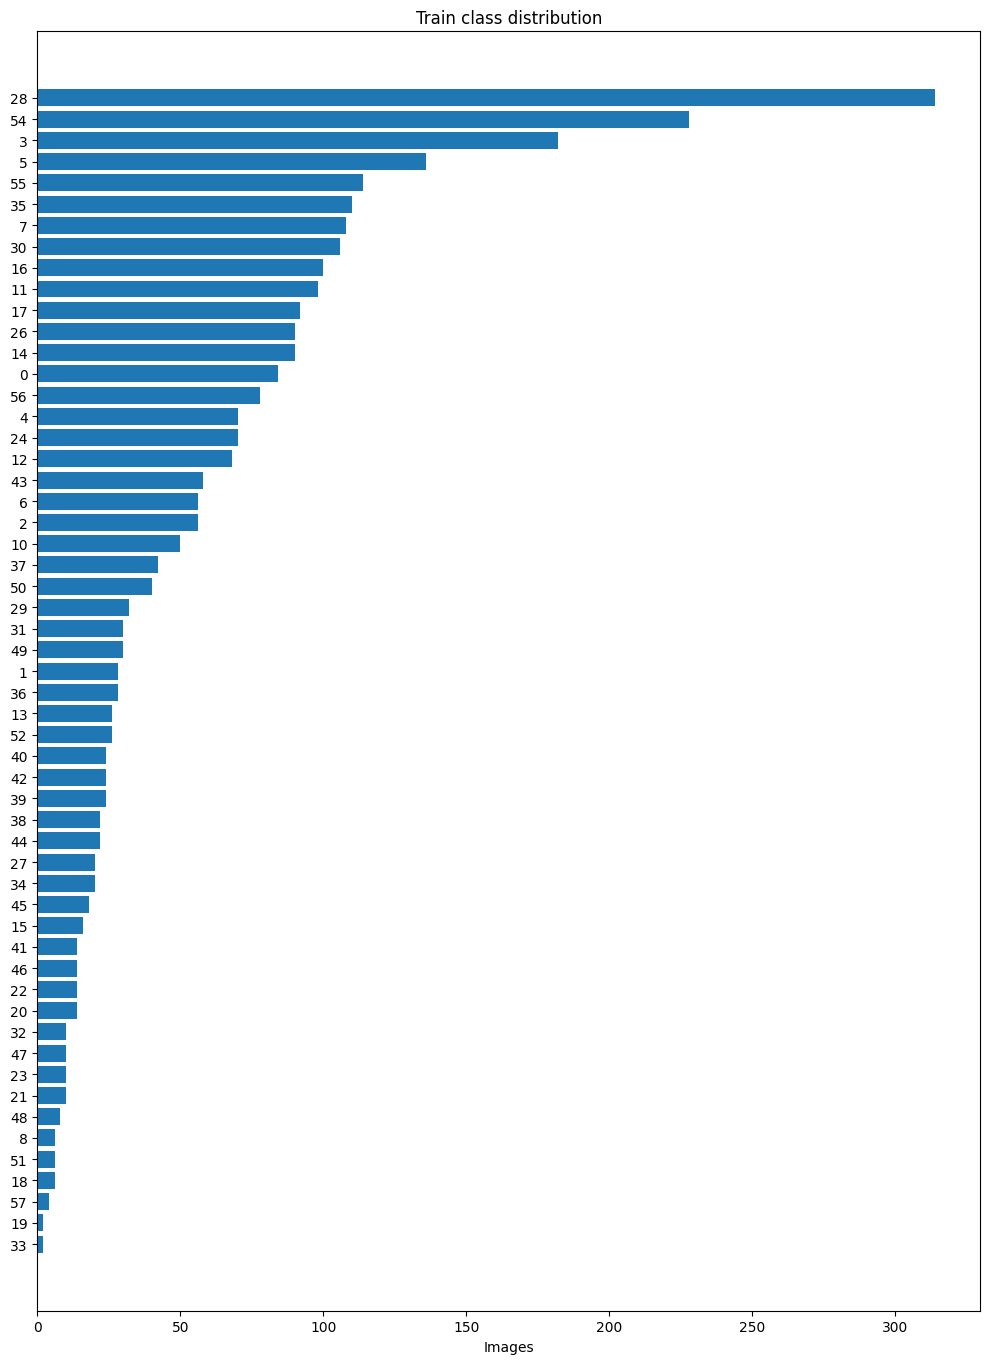

Dataset root: /content/data/processed/traffic-sign-classification
Classes: 58


In [33]:
DATASET_ROOT = Path(RUNTIME_DATA_ROOT if "RUNTIME_DATA_ROOT" in globals() else CLASSIFICATION_ROOT)

class_names = sorted({
    class_dir.name
    for split in ["train", "val", "test"]
    for class_dir in (DATASET_ROOT / split).iterdir()
    if (DATASET_ROOT / split).exists() and class_dir.is_dir()
})

name_to_id = {name: i for i, name in enumerate(class_names)}
names = {i: name for name, i in name_to_id.items()}

records = []

for split in ["train", "val", "test"]:
    split_dir = DATASET_ROOT / split

    if not split_dir.exists():
        continue

    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        class_name = class_dir.name
        class_id = name_to_id[class_name]

        for image_path in sorted(class_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "split": split,
                    "image_path": image_path,
                    "class_id": class_id,
                    "class_name": class_name,
                })

labels_df = pd.DataFrame(records)
images_df = labels_df.copy()

class_counts = (
    labels_df
    .groupby(["split", "class_id", "class_name"])
    .size()
    .reset_index(name="images")
    .sort_values(["split", "images"], ascending=[True, False])
)

display_styled_table(class_counts, "Class Distribution", 120)

train_counts = class_counts[class_counts["split"] == "train"].sort_values("images")

plt.figure(figsize=(10, max(8, len(train_counts) * 0.25)))
plt.barh(train_counts["class_name"], train_counts["images"])
plt.title("Train class distribution")
plt.xlabel("Images")
plt.tight_layout()
plt.show()

print("Dataset root:", DATASET_ROOT)
print("Classes:", len(names))

## **`4. DATA CLEANING`**

L

In [34]:
DATASET_ROOT = Path(RUNTIME_DATA_ROOT if "RUNTIME_DATA_ROOT" in globals() else CLASSIFICATION_ROOT)

CLEAN_ROOT = DATA_ROOT / "processed" / "traffic-sign-classification-clean"
RUNTIME_DATA_ROOT = CLEAN_ROOT

def sha256_file(path: Path):
    import hashlib
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

if CLEAN_ROOT.exists():
    shutil.rmtree(CLEAN_ROOT)

seen_hashes = set()
clean_report = {"summary": {}, "rejected": []}

records = []

for split in ["train", "val", "test"]:
    split_dir = DATASET_ROOT / split
    kept = 0
    removed = 0
    reasons_counter = Counter()

    if not split_dir.exists():
        clean_report["summary"][split] = {
            "total": 0,
            "kept": 0,
            "removed": 0,
            "reasons": {"missing_split": 1},
        }
        continue

    image_paths = sorted([
        p for p in split_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    for image_path in image_paths:
        class_name = image_path.parent.name
        reasons = []

        image = cv2.imread(str(image_path))
        if image is None:
            reasons.append("unreadable_image")

        image_hash = None
        if image is not None:
            image_hash = sha256_file(image_path)
            if image_hash in seen_hashes:
                reasons.append("duplicate_file")

        if reasons:
            removed += 1
            reasons_counter.update(reasons)
            clean_report["rejected"].append({
                "split": split,
                "class_name": class_name,
                "image": str(image_path),
                "reason": ";".join(reasons),
            })
            continue

        target = CLEAN_ROOT / split / class_name / image_path.name
        link_or_copy(image_path, target)

        seen_hashes.add(image_hash)
        kept += 1

        records.append({
            "split": split,
            "class_name": class_name,
            "image_path": target,
        })

    clean_report["summary"][split] = {
        "total": len(image_paths),
        "kept": kept,
        "removed": removed,
        "reasons": dict(reasons_counter),
    }

images_df = pd.DataFrame(records)

class_names = sorted(images_df["class_name"].unique().tolist())
name_to_id = {name: i for i, name in enumerate(class_names)}
names = {i: name for name, i in name_to_id.items()}

labels_df = images_df.copy()
labels_df["class_id"] = labels_df["class_name"].map(name_to_id)

(CLEAN_ROOT / "clean_report.json").write_text(
    json.dumps(clean_report, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

display_styled_table(
    pd.DataFrame([{"split": split, **info} for split, info in clean_report["summary"].items()]),
    "Cleaning Summary",
)

display_styled_table(
    labels_df.groupby(["split", "class_id", "class_name"]).size().reset_index(name="images"),
    "Clean Class Distribution",
    120,
)

print("Clean classification dataset:", CLEAN_ROOT)
print("Classes:", len(names))

,split,total,kept,removed,reasons
0,train,2960,1538,1422,{'duplicate_file': 1422}
1,val,605,99,506,{'duplicate_file': 506}
2,test,605,35,570,{'duplicate_file': 570}


,split,class_id,class_name,images
0,test,0,0,2
1,test,1,1,2
2,test,2,10,1
3,test,6,14,2
4,test,9,17,1
5,test,17,24,1
6,test,19,26,1
7,test,21,28,1
8,test,23,3,5
9,test,24,30,1


Clean classification dataset: /content/data/processed/traffic-sign-classification-clean
Classes: 58


## **`5. DATA PREPARING`**

Section nay tao dataset train that cho YOLO. Train split duoc can bang hon bang cach cap class qua nhieu va oversample class qua it. Val/test giu theo clean data sau remap de evaluation trung thuc.

In [35]:
SOURCE_DATA_ROOT = Path(RUNTIME_DATA_ROOT if "RUNTIME_DATA_ROOT" in globals() else CLASSIFICATION_ROOT)

TRAINING_ROOT = DATA_ROOT / "processed" / "traffic-sign-classification-training-balanced"
RUNTIME_DATA_ROOT = TRAINING_ROOT

MIN_TRAIN_IMAGES_PER_CLASS = 40
MAX_TRAIN_IMAGES_PER_CLASS = 180
MIN_TEST_IMAGES_FOR_REPORT = 5

if TRAINING_ROOT.exists():
    shutil.rmtree(TRAINING_ROOT)

class_names = sorted([
    p.name for p in (SOURCE_DATA_ROOT / "train").iterdir()
    if p.is_dir()
])

name_to_id = {name: i for i, name in enumerate(class_names)}
names = {i: name for name, i in name_to_id.items()}

rng = random.Random(42)
original_train_counts = Counter()
balanced_train_counts = Counter()

for class_name in class_names:
    source_class_dir = SOURCE_DATA_ROOT / "train" / class_name
    train_images = sorted([
        p for p in source_class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    original_train_counts[class_name] = len(train_images)

    if not train_images:
        continue

    rng.shuffle(train_images)

    selected = train_images[:MAX_TRAIN_IMAGES_PER_CLASS]

    duplicate_index = 0
    while len(selected) < MIN_TRAIN_IMAGES_PER_CLASS:
        selected.append(train_images[duplicate_index % len(train_images)])
        duplicate_index += 1

    for index, image_path in enumerate(selected):
        if index < len(train_images[:MAX_TRAIN_IMAGES_PER_CLASS]):
            out_name = image_path.name
        else:
            out_name = f"{image_path.stem}__dup{index:05d}{image_path.suffix}"

        target = TRAINING_ROOT / "train" / class_name / out_name
        link_or_copy(image_path, target)
        balanced_train_counts[class_name] += 1

for split in ["val", "test"]:
    split_dir = SOURCE_DATA_ROOT / split
    if not split_dir.exists():
        continue

    for class_name in class_names:
        source_class_dir = split_dir / class_name
        if not source_class_dir.exists():
            continue

        for image_path in sorted([
            p for p in source_class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]):
            target = TRAINING_ROOT / split / class_name / image_path.name
            link_or_copy(image_path, target)

records = []

for split in ["train", "val", "test"]:
    split_dir = TRAINING_ROOT / split
    if not split_dir.exists():
        continue

    for class_name in class_names:
        class_dir = split_dir / class_name
        if not class_dir.exists():
            continue

        for image_path in sorted([
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]):
            records.append({
                "split": split,
                "image_path": image_path,
                "class_id": name_to_id[class_name],
                "class_name": class_name,
            })

labels_df = pd.DataFrame(records)
images_df = labels_df.copy()

if images_df.empty:
    raise ValueError("No images found after preparing classification dataset.")

summary_df = (
    images_df
    .groupby("split")
    .agg(images=("image_path", "count"))
    .reset_index()
)
display_styled_table(summary_df, "Prepared Classification Dataset")

balance_rows = []
for class_name in class_names:
    balance_rows.append({
        "class_id": name_to_id[class_name],
        "class_name": class_name,
        "original_train_images": int(original_train_counts.get(class_name, 0)),
        "balanced_train_images": int(balanced_train_counts.get(class_name, 0)),
        "below_min_target": int(balanced_train_counts.get(class_name, 0)) < MIN_TRAIN_IMAGES_PER_CLASS,
        "above_max_target": int(balanced_train_counts.get(class_name, 0)) > MAX_TRAIN_IMAGES_PER_CLASS,
    })

display_styled_table(
    pd.DataFrame(balance_rows).sort_values("balanced_train_images"),
    "Train Image Balancing Report",
    120,
)

full_class_df = (
    labels_df
    .groupby(["split", "class_id", "class_name"])
    .size()
    .reset_index(name="images")
)

display_styled_table(
    full_class_df.sort_values(["split", "images"], ascending=[True, True]),
    "Image Count by Class",
    120,
)

test_support_df = full_class_df[full_class_df["split"] == "test"].copy()
test_support_df["enough_for_evaluation"] = test_support_df["images"] >= MIN_TEST_IMAGES_FOR_REPORT

display_styled_table(
    test_support_df.sort_values(["enough_for_evaluation", "images"], ascending=[True, True]),
    "Evaluation Support by Class",
    120,
)

print("Runtime classification data:", RUNTIME_DATA_ROOT)
print("Classes:", len(names))

,split,images
0,test,35
1,train,2583
2,val,96


,class_id,class_name,original_train_images,balanced_train_images,below_min_target,above_max_target
1,1,1,17,40,False,False
2,2,10,14,40,False,False
3,3,11,31,40,False,False
4,4,12,11,40,False,False
7,7,15,10,40,False,False
5,5,13,16,40,False,False
10,10,18,4,40,False,False
11,11,19,1,40,False,False
14,14,21,6,40,False,False
15,15,22,9,40,False,False


,split,class_id,class_name,images
2,test,2,10,1
4,test,9,17,1
5,test,17,24,1
6,test,18,26,1
7,test,20,28,1
9,test,23,30,1
10,test,25,32,1
12,test,29,36,1
13,test,30,37,1
14,test,31,38,1


,split,class_id,class_name,images,enough_for_evaluation
2,test,2,10,1,False
4,test,9,17,1,False
5,test,17,24,1,False
6,test,18,26,1,False
7,test,20,28,1,False
9,test,23,30,1,False
10,test,25,32,1,False
12,test,29,36,1,False
13,test,30,37,1,False
14,test,31,38,1,False


Runtime classification data: /content/data/processed/traffic-sign-classification-training-balanced
Classes: 55


## **`6. MODEL TRAINING & VALIDATION`**

In [36]:
BASE_MODEL = "yolo11n-cls.pt"
model = YOLO(BASE_MODEL)

train_results = model.train(
    data=str(RUNTIME_DATA_ROOT),
    epochs=10,
    imgsz=224,
    batch=32,
    workers=2,
    project=str(PROJECT_ROOT / "runs" / "train"),
    name="traffic-sign-yolo-cls",
    seed=42,
    patience=5,
    exist_ok=True,
    plots=True,
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/processed/traffic-sign-classification-training-balanced, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic-sign-yolo-cls, nbs=64, nms=False, opset=None, 

## **`7. MODEL EVALUATION`**

In [38]:
# 7. MODEL EVALUATION - YOLO Classification

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd().resolve()

if "RUN_NAME" not in globals():
    RUN_NAME = "traffic-sign-yolo-cls"

if "RUNTIME_DATA_ROOT" not in globals():
    if "TRAINING_ROOT" in globals():
        RUNTIME_DATA_ROOT = TRAINING_ROOT
    elif "CLASSIFICATION_ROOT" in globals():
        RUNTIME_DATA_ROOT = CLASSIFICATION_ROOT
    else:
        raise NameError("Chua co RUNTIME_DATA_ROOT. Hay chay lai cell Data Preparing truoc.")

if "BEST_WEIGHT" not in globals():
    candidate = PROJECT_ROOT / "runs" / "train" / RUN_NAME / "weights" / "best.pt"

    if candidate.exists():
        BEST_WEIGHT = candidate
    else:
        train_runs_dir = PROJECT_ROOT / "runs" / "train"
        best_candidates = (
            sorted(train_runs_dir.rglob("best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
            if train_runs_dir.exists()
            else []
        )

        if not best_candidates:
            raise FileNotFoundError(
                "Khong tim thay best.pt. Hay chay cell MODEL TRAINING truoc khi evaluation."
            )

        BEST_WEIGHT = best_candidates[0]

if not Path(BEST_WEIGHT).exists():
    raise FileNotFoundError(f"Missing weight: {BEST_WEIGHT}")

eval_model = YOLO(str(BEST_WEIGHT))

eval_split = "test" if (Path(RUNTIME_DATA_ROOT) / "test").exists() else "val"

metrics = eval_model.val(
    data=str(RUNTIME_DATA_ROOT),
    split=eval_split,
    imgsz=224,
    project=str(PROJECT_ROOT / "runs" / "eval"),
    name=f"{RUN_NAME}-{eval_split}",
    plots=True,
)

evaluation_df = pd.DataFrame([{
    "run_name": RUN_NAME,
    "split": eval_split,
    "top1_accuracy": float(metrics.top1),
    "top5_accuracy": float(metrics.top5),
    "best_weight": str(BEST_WEIGHT),
}])

display_styled_table(evaluation_df, "Evaluation Metrics")

print("Evaluation weight:", BEST_WEIGHT)
print("Evaluation data:", RUNTIME_DATA_ROOT)
print("Evaluation split:", eval_split)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,596,479 parameters, 0 gradients, 3.2 GFLOPs
train: /content/data/processed/traffic-sign-classification-training-balanced/train... found 2583 images in 55 classes ✅ 
ERROR ❌ val: /content/data/processed/traffic-sign-classification-training-balanced/val... found 96 images in 34 classes (requires 55 classes, not 34)
ERROR ❌ test: /content/data/processed/traffic-sign-classification-training-balanced/test... found 35 images in 22 classes (requires 55 classes, not 22)
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 544.2±385.9 MB/s, size: 27.6 KB)
test: Scanning /content/data/processed/traffic-sign-classification-training-balanced/test... 35 images, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 4.0Kit/s 0.0s
test: New cache created: /content/data/processed/traffic-sign-classification-training-balanced/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3

,run_name,split,top1_accuracy,top5_accuracy,best_weight
0,traffic-sign-yolo-cls,test,0.028571,0.114286,/content/runs/train/traffic-sign-yolo-cls/weights/best.pt


Evaluation weight: /content/runs/train/traffic-sign-yolo-cls/weights/best.pt
Evaluation data: /content/data/processed/traffic-sign-classification-training-balanced
Evaluation split: test


## **`8. INFERENCE`**

In [ ]:
sample = images_df[images_df["split"] == "test"].sample(n=1, random_state=15).iloc[0]
result = eval_model.predict(source=str(sample["image_path"]), imgsz=224, verbose=False)[0]

probs = result.probs
rows = []
for class_id, conf in zip(probs.top5, probs.top5conf):
    class_id = int(class_id)
    rows.append({
        "class_id": class_id,
        "class_name": result.names[class_id],
        "confidence": float(conf),
    })

display_styled_table(pd.DataFrame(rows), "Top Predictions")

In [ ]:
# =========================
# Giao diện nhận diện biển báo giao thông YOLO - Colab
# Có Auto Tune Conf + Img size
# =========================

from ultralytics import YOLO
from IPython.display import display, clear_output
from pathlib import Path
from PIL import Image as PILImage
import ipywidgets as widgets
import pandas as pd
import numpy as np

# =========================
# 1. Load model
# =========================
model_path = "/content/runs/train/vietnam-traffic-sign-yolo-balanced/weights/best.pt"
model = YOLO(model_path)

# =========================
# 2. Config
# =========================
AUTO_FOCUS = True
FOCUS_PADDING = 0.25
MAX_DISPLAY_SIZE = (550, 550)

# Nếu bật, hệ thống tự chọn Conf + Img size trước khi predict chính
AUTO_TUNE_DEFAULT = True

upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=True
)

auto_tune_checkbox = widgets.Checkbox(
    value=AUTO_TUNE_DEFAULT,
    description="Tự chọn Conf + Img size"
)

conf_slider = widgets.FloatSlider(
    value=0.25,
    min=0.05,
    max=1.0,
    step=0.05,
    description="Conf:"
)

imgsz_slider = widgets.IntSlider(
    value=416,
    min=320,
    max=1024,
    step=32,
    description="Img size:"
)

predict_button = widgets.Button(
    description="Dự đoán ảnh",
    button_style="success"
)

output = widgets.Output()

# =========================
# 3. Helper functions
# =========================
def save_uploaded_images(upload_value, upload_dir: Path):
    upload_dir.mkdir(exist_ok=True)

    for old_file in upload_dir.glob("*"):
        old_file.unlink()

    image_paths = []

    if isinstance(upload_value, dict):
        for filename, file_info in upload_value.items():
            content = file_info["content"]
            save_path = upload_dir / filename
            with open(save_path, "wb") as f:
                f.write(content)
            image_paths.append(save_path)
    else:
        for file_info in upload_value:
            filename = file_info["name"]
            content = file_info["content"]
            save_path = upload_dir / filename
            with open(save_path, "wb") as f:
                f.write(content)
            image_paths.append(save_path)

    return image_paths


def resize_for_display(pil_img, max_size=MAX_DISPLAY_SIZE):
    img = pil_img.copy()
    img.thumbnail(max_size)
    return img


def crop_focus_area(pil_img, boxes, padding=0.25):
    if boxes is None or len(boxes) == 0:
        return pil_img.copy()

    w, h = pil_img.size

    xyxy_list = []
    for box in boxes:
        xyxy = box.xyxy[0].tolist()
        xyxy_list.append(xyxy)

    xyxy_arr = np.array(xyxy_list)

    x1 = xyxy_arr[:, 0].min()
    y1 = xyxy_arr[:, 1].min()
    x2 = xyxy_arr[:, 2].max()
    y2 = xyxy_arr[:, 3].max()

    box_w = x2 - x1
    box_h = y2 - y1

    pad_x = box_w * padding
    pad_y = box_h * padding

    x1 = max(0, int(x1 - pad_x))
    y1 = max(0, int(y1 - pad_y))
    x2 = min(w, int(x2 + pad_x))
    y2 = min(h, int(y2 + pad_y))

    return pil_img.crop((x1, y1, x2, y2))


def prediction_rows(result, image_name):
    rows = []

    if result.boxes is None or len(result.boxes) == 0:
        return rows

    for i, box in enumerate(result.boxes):
        class_id = int(box.cls.item())
        confidence = float(box.conf.item())
        xyxy = box.xyxy[0].tolist()

        rows.append({
            "Ảnh": image_name,
            "STT": i + 1,
            "Biển báo": result.names[class_id],
            "Độ tin cậy": round(confidence, 3),
            "x1": round(xyxy[0], 1),
            "y1": round(xyxy[1], 1),
            "x2": round(xyxy[2], 1),
            "y2": round(xyxy[3], 1),
        })

    return rows


def show_detection_table(rows, title="Danh sách biển báo phát hiện được"):
    print(title)

    if not rows:
        df = pd.DataFrame([{
            "Kết quả": "Không phát hiện biển báo nào",
            "Gợi ý": "Thử giảm Conf xuống 0.15 - 0.20 hoặc dùng ảnh rõ hơn"
        }])
        display(df)
        return

    df = pd.DataFrame(rows)
    display(df)


def auto_tune_params(image_paths):
    """
    Tự chọn Conf + Img size theo heuristic.

    Ý tưởng:
    - Chạy thử nhiều cặp conf/imgsz.
    - Ưu tiên cấu hình có phát hiện.
    - Ưu tiên confidence trung bình cao.
    - Phạt nhẹ nếu phát hiện quá nhiều box vì có thể là false positive.
    """
    conf_candidates = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
    imgsz_candidates = [416, 512, 640]

    best_score = -999
    best_conf = conf_slider.value
    best_imgsz = imgsz_slider.value
    best_summary = None

    tune_records = []

    for imgsz in imgsz_candidates:
        for conf in conf_candidates:
            results = model.predict(
                source=[str(p) for p in image_paths],
                conf=conf,
                imgsz=imgsz,
                device=0,
                save=False,
                verbose=False
            )

            total_boxes = 0
            total_conf = 0.0
            images_with_detection = 0

            for result in results:
                if result.boxes is not None and len(result.boxes) > 0:
                    confs = result.boxes.conf.tolist()
                    total_boxes += len(confs)
                    total_conf += sum(confs)
                    images_with_detection += 1

            avg_conf = total_conf / total_boxes if total_boxes > 0 else 0.0

            # Heuristic score:
            # - Có ảnh detect được thì cộng mạnh
            # - Confidence cao thì cộng
            # - Box quá nhiều thì phạt nhẹ để tránh nhận lung tung
            # - Img size cao hơn một chút thì cộng nhẹ vì bắt biển nhỏ tốt hơn
            score = (
                images_with_detection * 2.0
                + avg_conf * 2.0
                + min(total_boxes, len(image_paths) * 3) * 0.25
                + (imgsz / 1000) * 0.1
                - max(0, total_boxes - len(image_paths) * 5) * 0.2
            )

            record = {
                "Conf": conf,
                "Img size": imgsz,
                "Số box": total_boxes,
                "Ảnh có detection": images_with_detection,
                "Conf trung bình": round(avg_conf, 3),
                "Score": round(score, 3),
            }
            tune_records.append(record)

            if score > best_score:
                best_score = score
                best_conf = conf
                best_imgsz = imgsz
                best_summary = record

    tune_df = pd.DataFrame(tune_records).sort_values("Score", ascending=False)

    return best_conf, best_imgsz, best_summary, tune_df


def display_original_and_prediction(original_path: Path, result):
    original_img = PILImage.open(original_path).convert("RGB")

    annotated_rgb = result.plot()[:, :, ::-1]
    annotated_img = PILImage.fromarray(annotated_rgb)

    original_show = resize_for_display(original_img)
    annotated_show = resize_for_display(annotated_img)

    original_out = widgets.Output()
    predicted_out = widgets.Output()

    with original_out:
        print("Ảnh ban đầu")
        display(original_show)

    with predicted_out:
        print("Ảnh sau dự đoán")
        display(annotated_show)

    display(widgets.HBox([original_out, predicted_out]))

    if AUTO_FOCUS and result.boxes is not None and len(result.boxes) > 0:
        focus_original = crop_focus_area(original_img, result.boxes, FOCUS_PADDING)
        focus_predicted = crop_focus_area(annotated_img, result.boxes, FOCUS_PADDING)

        focus_original = resize_for_display(focus_original)
        focus_predicted = resize_for_display(focus_predicted)

        focus_original_out = widgets.Output()
        focus_predicted_out = widgets.Output()

        with focus_original_out:
            print("Ảnh ban đầu - vùng focus")
            display(focus_original)

        with focus_predicted_out:
            print("Ảnh dự đoán - vùng focus")
            display(focus_predicted)

        display(widgets.HBox([focus_original_out, focus_predicted_out]))

    rows = prediction_rows(result, original_path.name)
    show_detection_table(rows, title=f"List biển báo trong ảnh: {original_path.name}")

    return rows


# =========================
# 4. Predict function
# =========================
def predict_images(b):
    with output:
        clear_output()

        if len(upload_widget.value) == 0:
            print("Bạn chưa upload ảnh.")
            return

        upload_dir = Path("/content/uploaded_images")
        image_paths = save_uploaded_images(upload_widget.value, upload_dir)

        print(f"Đã upload {len(image_paths)} ảnh.")

        if auto_tune_checkbox.value:
            print("Đang tự chọn Conf + Img size...\n")

            best_conf, best_imgsz, best_summary, tune_df = auto_tune_params(image_paths)

            conf_slider.value = best_conf
            imgsz_slider.value = best_imgsz

            print("Tham số được chọn tự động:")
            print(f"Conf: {best_conf}")
            print(f"Img size: {best_imgsz}")
            print(f"Số box: {best_summary['Số box']}")
            print(f"Conf trung bình: {best_summary['Conf trung bình']}")
            print(f"Score: {best_summary['Score']}")
            print()

            print("Top 5 cấu hình tốt nhất:")
            display(tune_df.head(5))
            print()

        print("Đang dự đoán với tham số cuối...\n")

        results = model.predict(
            source=[str(p) for p in image_paths],
            conf=conf_slider.value,
            imgsz=imgsz_slider.value,
            device=0,
            save=False,
            verbose=False
        )

        print("Kết quả dự đoán:\n")

        all_rows = []

        for image_path, result in zip(image_paths, results):
            print("=" * 100)
            print(f"Ảnh: {image_path.name}")

            rows = display_original_and_prediction(image_path, result)
            all_rows.extend(rows)

        print("=" * 100)
        show_detection_table(all_rows, title="Bảng tổng hợp tất cả biển báo phát hiện được")


predict_button.on_click(predict_images)

# =========================
# 5. Display UI
# =========================
display(widgets.VBox([
    widgets.HTML("<h3>Giao diện nhận diện biển báo giao thông bằng YOLO</h3>"),
    widgets.HTML("<b>Bước 1:</b> Chọn ảnh cần dự đoán"),
    upload_widget,
    widgets.HTML("<b>Bước 2:</b> Chọn chế độ tham số"),
    auto_tune_checkbox,
    widgets.HTML("<b>Nếu tắt auto, chỉnh tay tại đây:</b>"),
    conf_slider,
    imgsz_slider,
    widgets.HTML("<b>Bước 3:</b> Bấm dự đoán"),
    predict_button,
    output
]))